# Milestone 3: Baseline Models Comparison

## Models:
1. **mBART-50** - Encoder-decoder (611M params)
2. **mT5-base** - Encoder-decoder (580M params)  
3. **Llama 3.2-3B** - Decoder-only with LoRA

**Hardware**: T4 (16GB) sufficient | **Runtime**: ~6-8 hours total

In [ ]:
# Setup
!pip install -q transformers>=4.40.0 datasets accelerate peft bitsandbytes trl
!pip install -q sentencepiece evaluate rouge-score bert-score pandas matplotlib seaborn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.5 MB/s eta 0:00:00


In [ ]:
import os, json, random, gc
import numpy as np
import pandas as pd
import torch
from typing import List, Dict
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from datasets import Dataset

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

GPU: NVIDIA A100-SXM4-40GB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/dataset_nlp/cs_sum'
OUTPUT_DIR = '/content/drive/MyDrive/milestone3_baselines/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

Mounted at /content/drive


In [ ]:
def detect_language(text):
    text_lower = text.lower()
    chinese = sum(1 for c in text if '\u4e00' <= c <= '\u9fff')
    tamil_words = ['naan', 'neenga', 'romba', 'irukku', 'illa', 'aana', 'theriyum', 'aama', 'kitta', 'kandippa']
    tamil_count = sum(1 for w in tamil_words if w in text_lower)
    malay_words = ['saya', 'apa', 'ini', 'itu', 'tidak', 'boleh', 'sudah', 'dengan', 'untuk', 'yang', 'ada']
    malay_count = sum(1 for w in malay_words if w in text_lower)
    if chinese > 3: return 'chinese-english'
    if tamil_count >= 2: return 'tamil-english'
    if malay_count >= 2: return 'malay-english'
    return 'english-dominant'

def load_jsonl(filepath):
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            item = json.loads(line)
            conv = '\n'.join([f"{m['author']}: {m['text']}" for m in item['messages']])
            data.append({'id': item['thread_id'], 'conversation': conv, 'summary': item['summary'], 'language': detect_language(conv)})
    return data

all_data = load_jsonl(f"{DATA_DIR}/cs_sum_train.jsonl")
code_mixed = [x for x in all_data if x['language'] in ['chinese-english', 'tamil-english', 'malay-english']]
random.shuffle(code_mixed)
n = len(code_mixed)
train_set, val_set, test_set = code_mixed[:int(n*0.85)], code_mixed[int(n*0.85):int(n*0.93)], code_mixed[int(n*0.93):]

test_by_lang = defaultdict(list)
for item in test_set: test_by_lang[item['language']].append(item)

print(f"Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_set)}")

Train: 1547, Val: 146, Test: 128


In [ ]:
zero_shot_test = {
    'japanese-english': [
        {'id': 'ja-1', 'conversation': "Yuki: Hey, meeting how was it?\nKen: maamaa dattayo. Client seemed happy.\nYuki: yokatta!", 'summary': 'Ken tells Yuki the client meeting went well.'},
        {'id': 'ja-2', 'conversation': "Sakura: Did you watch the anime?\nHiro: aa, mitayo! sugoi!\nSakura: Animation was hontoni impressive.", 'summary': 'Sakura and Hiro loved the new anime.'},
        {'id': 'ja-3', 'conversation': "Mei: lunch ikanai?\nTaro: Sure! ramen?\nMei: OK, 12ji ni!", 'summary': 'Mei and Taro plan ramen lunch at noon.'}
    ],
    'korean-english': [
        {'id': 'ko-1', 'conversation': "Jimin: oneul jeonyeoke mwo hae?\nSoyeon: Nothing.\nJimin: saeroun restaurant opened. 7si?", 'summary': 'Jimin invites Soyeon to a new restaurant at 7pm.'},
        {'id': 'ko-2', 'conversation': "Minho: Homework haesseo?\nEunji: ajik... Hard.\nMinho: doseogwan 3si?", 'summary': 'Minho and Eunji plan to study at library at 3pm.'},
        {'id': 'ko-3', 'conversation': "Hyun: Concert eottaesseo?\nJisoo: daebak! Close seats yeosseo!", 'summary': 'Jisoo loved the concert with close seats.'}
    ],
    'hindi-english': [
        {'id': 'hi-1', 'conversation': "Raj: Match dekha?\nAmit: Haan! India ki bowling was fire.\nRaj: Kohli ka century!", 'summary': "Raj and Amit praise India's cricket performance."},
        {'id': 'hi-2', 'conversation': "Priya: Office mein bahut kaam.\nNeha: Same! Boss ne 3 projects diye.\nPriya: Overtime?", 'summary': 'Priya and Neha discuss heavy workload.'},
        {'id': 'hi-3', 'conversation': "Arjun: Party plan?\nVikram: DJ booked. Biryani for 50 log.", 'summary': 'Arjun and Vikram plan party with DJ and biryani.'}
    ]
}

In [ ]:
import evaluate
rouge = evaluate.load('rouge')
bertscore = evaluate.load('bertscore')

def calc_metrics(preds, refs, name):
    print(f"  Metrics: {name}")
    preds = [p.strip() if p else "" for p in preds]
    refs = [r.strip() if r else "" for r in refs]
    r = rouge.compute(predictions=preds, references=refs, use_stemmer=True)
    torch.cuda.empty_cache()
    b = bertscore.compute(predictions=preds, references=refs, lang="en", model_type="microsoft/deberta-v3-base", batch_size=8)
    torch.cuda.empty_cache()
    return {'rouge1': r['rouge1'], 'rouge2': r['rouge2'], 'rougeL': r['rougeL'], 'bertscore': np.mean(b['f1']), 'avg_len': np.mean([len(p.split()) for p in preds])}

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


---
## Model 1: mBART-50

In [ ]:
from transformers import MBartForConditionalGeneration, MBart50TokenizerFast, Seq2SeqTrainer, Seq2SeqTrainingArguments, DataCollatorForSeq2Seq

print("Loading mBART-50...")
mbart_tok = MBart50TokenizerFast.from_pretrained("facebook/mbart-large-50-many-to-many-mmt")
mbart_model = MBartForConditionalGeneration.from_pretrained("facebook/mbart-large-50-many-to-many-mmt")
mbart_tok.src_lang = "en_XX"
print(f"mBART: {mbart_model.num_parameters()/1e6:.0f}M params")

Loading mBART-50...


tokenizer_config.json:   0%|          | 0.00/529 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/649 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/2.44G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/261 [00:00<?, ?B/s]

mBART: 611M params


In [ ]:
# Make sure tgt_lang is set
mbart_tok.src_lang = "en_XX"
mbart_tok.tgt_lang = "en_XX"

def prep_mbart(ex):
    # Inputs
    inp = mbart_tok(ex['conversation'], max_length=512, truncation=True, padding='max_length')
    # Labels
    lab = mbart_tok(ex['summary'], max_length=128, truncation=True, padding='max_length')
    inp['labels'] = lab['input_ids']
    return inp

print("Preprocessing data...")
train_mbart = Dataset.from_list(train_set).map(prep_mbart, batched=True, remove_columns=['id','conversation','summary','language'])
val_mbart = Dataset.from_list(val_set).map(prep_mbart, batched=True, remove_columns=['id','conversation','summary','language'])
print(f"Done! Train: {len(train_mbart)}, Val: {len(val_mbart)}")

Preprocessing data...


Map:   0%|          | 0/1547 [00:00<?, ? examples/s]

Map:   0%|          | 0/146 [00:00<?, ? examples/s]

Done! Train: 1547, Val: 146


In [ ]:
mbart_args = Seq2SeqTrainingArguments(
    output_dir="./mbart", num_train_epochs=3, per_device_train_batch_size=4, gradient_accumulation_steps=4,
    learning_rate=3e-5, warmup_ratio=0.1, logging_steps=50, eval_strategy="steps", eval_steps=200,
    save_strategy="steps", save_steps=200, save_total_limit=2, load_best_model_at_end=True,
    predict_with_generate=True, generation_max_length=128, bf16=True, report_to="none")

mbart_trainer = Seq2SeqTrainer(model=mbart_model, args=mbart_args, train_dataset=train_mbart, eval_dataset=val_mbart,
                               data_collator=DataCollatorForSeq2Seq(mbart_tok, model=mbart_model), tokenizer=mbart_tok)
print("Training mBART...")
mbart_trainer.train()
print("mBART done!")

/tmp/ipython-input-2742802490.py:7: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  mbart_trainer = Seq2SeqTrainer(model=mbart_model, args=mbart_args, train_dataset=train_mbart, eval_dataset=val_mbart,


Training mBART...


Step,Training Loss,Validation Loss
200,0.322800,0.397747


/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 200, 'early_stopping': True, 'num_beams': 5}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


mBART done!


In [ ]:
def gen_mbart(test_data):
    mbart_model.eval()
    preds = []
    for i in tqdm(range(0, len(test_data), 8)):
        batch = test_data[i:i+8]
        inp = mbart_tok([x['conversation'] for x in batch], max_length=512, truncation=True, padding=True, return_tensors="pt").to(mbart_model.device)
        with torch.no_grad():
            out = mbart_model.generate(**inp, max_length=128, num_beams=4, forced_bos_token_id=mbart_tok.lang_code_to_id["en_XX"])
        preds.extend(mbart_tok.batch_decode(out, skip_special_tokens=True))
    return preds

print("Generating mBART predictions...")
mbart_in = {lang: gen_mbart(items) for lang, items in test_by_lang.items()}
mbart_zs = {lang: gen_mbart(items) for lang, items in zero_shot_test.items()}

Generating mBART predictions...


  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
del mbart_model, mbart_trainer
torch.cuda.empty_cache()
gc.collect()
print("mBART cleared")

mBART cleared


---
## Model 2: mT5-base

In [ ]:
from transformers import MT5ForConditionalGeneration, MT5Tokenizer

print("Loading mT5-base...")
mt5_tok = MT5Tokenizer.from_pretrained("google/mt5-base")
mt5_model = MT5ForConditionalGeneration.from_pretrained("google/mt5-base")
print(f"mT5: {mt5_model.num_parameters()/1e6:.0f}M params")

Loading mT5-base...


tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/702 [00:00<?, ?B/s]

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'T5Tokenizer'. 
The class this function is called from is 'MT5Tokenizer'.
You are using the default legacy behaviour of the <class 'transformers.models.mt5.tokenization_mt5.MT5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


pytorch_model.bin:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

mT5: 582M params


In [ ]:
def prep_mt5(ex):
    inp = mt5_tok([f"summarize: {c}" for c in ex['conversation']], max_length=512, truncation=True, padding='max_length')
    lab = mt5_tok(ex['summary'], max_length=128, truncation=True, padding='max_length')
    inp['labels'] = lab['input_ids']
    return inp

train_mt5 = Dataset.from_list(train_set).map(prep_mt5, batched=True, remove_columns=['id','conversation','summary','language'])
val_mt5 = Dataset.from_list(val_set).map(prep_mt5, batched=True, remove_columns=['id','conversation','summary','language'])

Map:   0%|          | 0/1547 [00:00<?, ? examples/s]

Map:   0%|          | 0/146 [00:00<?, ? examples/s]

In [ ]:
mt5_args = Seq2SeqTrainingArguments(
    output_dir="./mt5", num_train_epochs=3, per_device_train_batch_size=4, gradient_accumulation_steps=4,
    learning_rate=3e-5, warmup_ratio=0.1, logging_steps=50, eval_strategy="steps", eval_steps=200,
    save_strategy="steps", save_steps=200, save_total_limit=2, load_best_model_at_end=True,
    predict_with_generate=True, generation_max_length=128, bf16=True, report_to="none")

mt5_trainer = Seq2SeqTrainer(model=mt5_model, args=mt5_args, train_dataset=train_mt5, eval_dataset=val_mt5,
                             data_collator=DataCollatorForSeq2Seq(mt5_tok, model=mt5_model), tokenizer=mt5_tok)
print("Training mT5...")
mt5_trainer.train()
print("mT5 done!")

/tmp/ipython-input-4283102897.py:7: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  mt5_trainer = Seq2SeqTrainer(model=mt5_model, args=mt5_args, train_dataset=train_mt5, eval_dataset=val_mt5,


Training mT5...


Step,Training Loss,Validation Loss
200,16.833400,13.683618


model.safetensors:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


mT5 done!


In [ ]:
def gen_mt5(test_data):
    mt5_model.eval()
    preds = []
    for i in tqdm(range(0, len(test_data), 8)):
        batch = test_data[i:i+8]
        inp = mt5_tok([f"summarize: {x['conversation']}" for x in batch], max_length=512, truncation=True, padding=True, return_tensors="pt").to(mt5_model.device)
        with torch.no_grad():
            out = mt5_model.generate(**inp, max_length=128, num_beams=4)
        preds.extend(mt5_tok.batch_decode(out, skip_special_tokens=True))
    return preds

print("Generating mT5 predictions...")
mt5_in = {lang: gen_mt5(items) for lang, items in test_by_lang.items()}
mt5_zs = {lang: gen_mt5(items) for lang, items in zero_shot_test.items()}

Generating mT5 predictions...


  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
del mt5_model, mt5_trainer
torch.cuda.empty_cache()
gc.collect()
print("mT5 cleared")

mT5 cleared


---
## Model 3: Llama 3.2-3B

In [ ]:
# Login to Hugging Face
from huggingface_hub import login

# Option 1: Interactive login (will prompt for token)
login()

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig

print("Loading Llama 3.2-3B...")
bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True)
llama_tok = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-3B-Instruct")
llama_tok.pad_token = llama_tok.eos_token
llama_tok.padding_side = "right"
llama_model = AutoModelForCausalLM.from_pretrained("meta-llama/Llama-3.2-3B-Instruct", quantization_config=bnb, device_map="auto", torch_dtype=torch.bfloat16)
llama_model = prepare_model_for_kbit_training(llama_model)
print("Llama 3.2-3B loaded")

Loading Llama 3.2-3B...


tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/1.46G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Llama 3.2-3B loaded


In [ ]:
lora = LoraConfig(r=16, lora_alpha=32, lora_dropout=0.05, bias="none", task_type="CAUSAL_LM",
                  target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"])
llama_model = get_peft_model(llama_model, lora)
llama_model.print_trainable_parameters()

trainable params: 24,313,856 || all params: 3,237,063,680 || trainable%: 0.7511


In [ ]:
SYSTEM_PROMPT = "You summarize code-mixed conversations into clear English."

def fmt_llama(ex):
    text = f"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\n{SYSTEM_PROMPT}<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nSummarize:\n{ex['conversation']}<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n{ex['summary']}<|eot_id|>"
    return {"text": text}

def fmt_inf(conv):
    return f"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\n{SYSTEM_PROMPT}<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nSummarize:\n{conv}<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n"

train_llama = Dataset.from_list([fmt_llama(ex) for ex in train_set])

In [ ]:
# First, check what arguments SFTTrainer accepts
import inspect
from trl import SFTTrainer
print(inspect.signature(SFTTrainer.__init__))

(self, model: str | transformers.modeling_utils.PreTrainedModel, args: trl.trainer.sft_config.SFTConfig | transformers.training_args.TrainingArguments | None = None, data_collator: Optional[Callable[[list[Any]], dict[str, Any]]] = None, train_dataset: datasets.arrow_dataset.Dataset | datasets.iterable_dataset.IterableDataset | None = None, eval_dataset: datasets.arrow_dataset.Dataset | dict[str, datasets.arrow_dataset.Dataset] | None = None, processing_class: transformers.tokenization_utils_base.PreTrainedTokenizerBase | transformers.processing_utils.ProcessorMixin | None = None, compute_loss_func: collections.abc.Callable | None = None, compute_metrics: collections.abc.Callable[[transformers.trainer_utils.EvalPrediction], dict] | None = None, callbacks: list[transformers.trainer_callback.TrainerCallback] | None = None, optimizers: tuple[torch.optim.optimizer.Optimizer | None, torch.optim.lr_scheduler.LambdaLR | None] = (None, None), optimizer_cls_and_kwargs: tuple[type[torch.optim.opt

In [ ]:
llama_trainer = SFTTrainer(
    model=llama_model,
    train_dataset=train_llama,
    args=llama_args,
    processing_class=llama_tok,  # Correct parameter name
)

print("Training Llama 3.2-3B...")
llama_trainer.train()
print("Llama done!")

Adding EOS to train dataset:   0%|          | 0/1547 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/1547 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/1547 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 128009}.


Training Llama 3.2-3B...


Step,Training Loss
25,3.651400
50,3.141500
75,2.739800
100,2.655800
125,2.584200
150,2.567500
175,2.502700
200,2.470500
225,2.473800
250,2.469300


Llama done!


In [ ]:
def gen_llama(test_data):
    llama_model.eval()
    preds = []
    for item in tqdm(test_data):
        inp = llama_tok(fmt_inf(item['conversation']), return_tensors="pt", truncation=True, max_length=900)
        # Move to device with correct dtype
        inp = {k: v.to(llama_model.device) for k, v in inp.items()}

        with torch.no_grad(), torch.cuda.amp.autocast(dtype=torch.bfloat16):  # Add autocast
            out = llama_model.generate(
                **inp,
                max_new_tokens=100,
                do_sample=False,
                pad_token_id=llama_tok.eos_token_id
            )
        preds.append(llama_tok.decode(out[0][inp['input_ids'].shape[1]:], skip_special_tokens=True).strip())
    return preds

print("Generating Llama predictions...")
llama_in = {lang: gen_llama(items) for lang, items in test_by_lang.items()}
llama_zs = {lang: gen_llama(items) for lang, items in zero_shot_test.items()}

Generating Llama predictions...


  0%|          | 0/65 [00:00<?, ?it/s]

/tmp/ipython-input-2072305173.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(dtype=torch.bfloat16):  # Add autocast


  0%|          | 0/41 [00:00<?, ?it/s]

  0%|          | 0/22 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

---
## Evaluation

In [ ]:
results = []
models_preds = {'mBART-50': (mbart_in, mbart_zs), 'mT5-base': (mt5_in, mt5_zs), 'Llama-3.2-3B': (llama_in, llama_zs)}

print("Calculating metrics...")
for model_name, (in_preds, zs_preds) in models_preds.items():
    for lang, preds in in_preds.items():
        refs = [x['summary'] for x in test_by_lang[lang]]
        m = calc_metrics(preds, refs, f"{model_name} {lang}")
        results.append({'Model': model_name, 'Language': lang, 'Type': 'IN-DOMAIN', **m})
    for lang, preds in zs_preds.items():
        refs = [x['summary'] for x in zero_shot_test[lang]]
        m = calc_metrics(preds, refs, f"{model_name} {lang} ZS")
        results.append({'Model': model_name, 'Language': lang, 'Type': 'ZERO-SHOT', **m})

Calculating metrics...
  Metrics: mBART-50 chinese-english


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

  Metrics: mBART-50 tamil-english
  Metrics: mBART-50 malay-english
  Metrics: mBART-50 japanese-english ZS
  Metrics: mBART-50 korean-english ZS
  Metrics: mBART-50 hindi-english ZS
  Metrics: mT5-base chinese-english
  Metrics: mT5-base tamil-english
  Metrics: mT5-base malay-english
  Metrics: mT5-base japanese-english ZS
  Metrics: mT5-base korean-english ZS
  Metrics: mT5-base hindi-english ZS
  Metrics: Llama-3.2-3B chinese-english
  Metrics: Llama-3.2-3B tamil-english
  Metrics: Llama-3.2-3B malay-english
  Metrics: Llama-3.2-3B japanese-english ZS
  Metrics: Llama-3.2-3B korean-english ZS
  Metrics: Llama-3.2-3B hindi-english ZS


In [ ]:
df = pd.DataFrame(results)
display_df = df.copy()
for c in ['rouge1','rouge2','rougeL','bertscore']:
    display_df[c] = display_df[c].apply(lambda x: f"{x:.4f}")

print("\n" + "="*100)
print("BASELINE MODELS COMPARISON")
print("="*100)
print(display_df.to_string(index=False))


BASELINE MODELS COMPARISON
       Model         Language      Type rouge1 rouge2 rougeL bertscore   avg_len
    mBART-50  chinese-english IN-DOMAIN 0.4231 0.1663 0.3334    0.6597 18.492308
    mBART-50    tamil-english IN-DOMAIN 0.3724 0.1148 0.2934    0.6135 17.292683
    mBART-50    malay-english IN-DOMAIN 0.4138 0.1560 0.3365    0.6366 16.545455
    mBART-50 japanese-english ZERO-SHOT 0.5407 0.2133 0.5407    0.7478  7.666667
    mBART-50   korean-english ZERO-SHOT 0.2281 0.0000 0.2281    0.6072  8.000000
    mBART-50    hindi-english ZERO-SHOT 0.2454 0.0000 0.2103    0.5807  7.333333
    mT5-base  chinese-english IN-DOMAIN 0.0678 0.0093 0.0613    0.3623  3.938462
    mT5-base    tamil-english IN-DOMAIN 0.0472 0.0035 0.0466    0.3498  3.439024
    mT5-base    malay-english IN-DOMAIN 0.0779 0.0182 0.0677    0.3932  3.272727
    mT5-base japanese-english ZERO-SHOT 0.0000 0.0000 0.0000    0.3615  2.000000
    mT5-base   korean-english ZERO-SHOT 0.0513 0.0000 0.0513    0.3835  2.333333


In [ ]:
print("\nAVERAGE ROUGE-L BY MODEL")
print("="*60)
for model in df['Model'].unique():
    in_dom = df[(df['Model']==model) & (df['Type']=='IN-DOMAIN')]['rougeL'].mean()
    zs = df[(df['Model']==model) & (df['Type']=='ZERO-SHOT')]['rougeL'].mean()
    transfer = (zs/in_dom)*100 if in_dom > 0 else 0
    print(f"{model}: In-domain={in_dom:.4f}, Zero-shot={zs:.4f} ({transfer:.1f}% transfer)")


AVERAGE ROUGE-L BY MODEL
mBART-50: In-domain=0.3211, Zero-shot=0.3264 (101.7% transfer)
mT5-base: In-domain=0.0585, Zero-shot=0.0726 (124.1% transfer)
Llama-3.2-3B: In-domain=0.2972, Zero-shot=0.4370 (147.0% transfer)


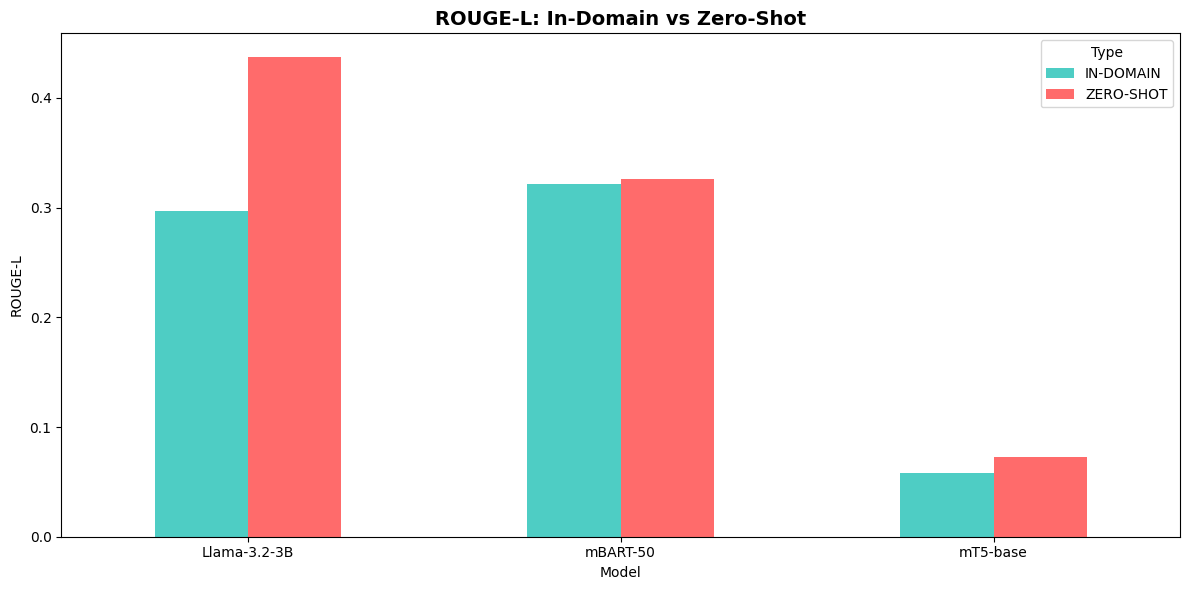

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
pivot = df.pivot_table(values='rougeL', index='Model', columns='Type', aggfunc='mean')
pivot.plot(kind='bar', ax=ax, color=['#4ECDC4', '#FF6B6B'])
ax.set_title('ROUGE-L: In-Domain vs Zero-Shot', fontsize=14, fontweight='bold')
ax.set_ylabel('ROUGE-L')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('baselines_comparison.png', dpi=150)
plt.show()

In [ ]:
df.to_csv('baselines_results.csv', index=False)
!cp baselines_results.csv "{OUTPUT_DIR}"
!cp baselines_comparison.png "{OUTPUT_DIR}"
print(f"Results saved to {OUTPUT_DIR}")

Results saved to /content/drive/MyDrive/milestone3_baselines/


In [ ]:
print("\n" + "="*80)
print("BASELINES SUMMARY")
print("="*80)
print("Models: mBART-50 (611M), mT5-base (580M), Llama-3.2-3B (LoRA)")
best_in = df[df['Type']=='IN-DOMAIN'].groupby('Model')['rougeL'].mean().idxmax()
best_zs = df[df['Type']=='ZERO-SHOT'].groupby('Model')['rougeL'].mean().idxmax()
print(f"Best in-domain: {best_in}")
print(f"Best zero-shot: {best_zs}")
print("="*80)


BASELINES SUMMARY
Models: mBART-50 (611M), mT5-base (580M), Llama-3.2-3B (LoRA)
Best in-domain: mBART-50
Best zero-shot: Llama-3.2-3B
